In [5]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk

WESAD_PATH = "/home/alma/bot/kairos-mentor/kairos_app/dataset/WESAD"
SUBJECT = "S2"

In [4]:
with open(f"{WESAD_PATH}/{SUBJECT}/{SUBJECT}.pkl", 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print("Claves principales:", list(data.keys()))
print("Señales de muñeca:", list(data['signal']['wrist'].keys()))
print("Señales de pecho:", list(data['signal']['chest'].keys()))
print("Shape labels:", data['label'].shape)

/tmp/ipykernel_70603/2063694849.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding='latin1')


Claves principales: ['signal', 'label', 'subject']
Señales de muñeca: ['ACC', 'BVP', 'EDA', 'TEMP']
Señales de pecho: ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
Shape labels: (4255300,)


In [1]:
"**Extraer señales**"

'**Extraer señales**'

In [6]:
# Extraemos la señal BVP (Blood Volume Pulse) desde el diccionario de datos.
# Está en la muñeca (wrist) y viene como array posiblemente 2D, por eso usamos flatten()
# para convertirla en un vector 1D.
# Frecuencia de muestreo: 64 Hz → 64 muestras por segundo.
bvp = data['signal']['wrist']['BVP'].flatten()   # 64 Hz


# Extraemos la señal del acelerómetro (ACC).
# Tiene 3 ejes: X, Y, Z → por eso NO hacemos flatten(), queremos mantener esa estructura.
# Frecuencia de muestreo: 32 Hz → 32 muestras por segundo.
acc = data['signal']['wrist']['ACC']              # 32 Hz, 3 ejes


# Extraemos las etiquetas (labels), que indican el estado del sujeto
# Vienen a una frecuencia MUY alta: 700 Hz.
# Usamos flatten() para tenerlas como vector 1D.
labels = data['label'].flatten()                  # 700 Hz

# shape → cantidad total de muestras
# len(bvp)/64 → duración en segundos (porque sabemos que está a 64 Hz)
# /60 → lo pasamos a minutos
print(f"BVP: {bvp.shape} muestras → {len(bvp)/64/60:.1f} minutos")

# shape del ACC → debería ser (n_muestras, 3) por los 3 ejes
print(f"ACC: {acc.shape}")

# np.unique(labels) → vemos qué valores distintos hay en las etiquetas
# (por ejemplo: [1, 2, 3] dependiendo de las clases del dataset)
print(f"Labels únicos: {np.unique(labels)}")

BVP: (389056,) muestras → 101.3 minutos
ACC: (194528, 3)
Labels únicos: [0 1 2 3 4 6 7]


In [ ]:
"**Ver distribución de clases**"

In [8]:
# Creamos un diccionario que traduce los números de las etiquetas
# a nombres más entendibles (clases del experimento).
clase_nombres = {1: 'Baseline', 2: 'Estrés', 3: 'Afecto positivo'}

# k = número de clase (1, 2, 3)
# v = nombre descriptivo ('Baseline', etc.)
for k, v in clase_nombres.items():

    # Contamos cuántas muestras del vector "labels" pertenecen a esa clase
    # (labels == k genera un array de True/False, y np.sum cuenta los True)
    n = np.sum(labels == k)

    # Mostramos:
    # - cantidad de muestras de esa clase
    # - duración en minutos
    #   (labels está a 700 Hz → dividimos por 700 para segundos y por 60 para minutos)
    print(f"Clase {k} ({v}): {n} muestras → {n/700/60:.1f} minutos")

Clase 1 (Baseline): 800800 muestras → 19.1 minutos
Clase 2 (Estrés): 430500 muestras → 10.2 minutos
Clase 3 (Afecto positivo): 253400 muestras → 6.0 minutos


In [ ]:
"**Sincronizar labels al BVP (64 Hz)**"

In [11]:
# Creamos un conjunto de índices para mapear las etiquetas (700 Hz)
# a la longitud de la señal BVP (64 Hz).
# np.linspace genera valores equiespaciados entre 0 y len(labels)-1
# pero con la cantidad de puntos igual a len(bvp)
indices_bvp = np.linspace(0, len(labels)-1, len(bvp))


# Interpolamos las etiquetas originales (700 Hz) para que coincidan
# con los puntos de la señal BVP (64 Hz).
# np.interp toma:
# - nuevos puntos (indices_bvp)
# - puntos originales (np.arange(len(labels)))
# - valores originales (labels)
labels_64hz = np.interp(indices_bvp, np.arange(len(labels)), labels)


# Como la interpolación genera valores decimales (ej: 1.7, 2.3),
# los redondeamos al entero más cercano para volver a tener clases válidas (1, 2, 3)
labels_64hz = np.round(labels_64hz).astype(int)

# Todas las muestras de BVP donde la etiqueta es "Baseline"
baseline_bvp = bvp[labels_64hz == 1]

# Todas las muestras de BVP donde la etiqueta es "Estrés"
stress_bvp   = bvp[labels_64hz == 2]

# Mostramos cuántas muestras hay de cada clase en BVP
print(f"BVP baseline: {len(baseline_bvp)} muestras")
print(f"BVP estrés:   {len(stress_bvp)} muestras") 

BVP baseline: 73216 muestras
BVP estrés:   39360 muestras


In [ ]:
"** Visualizar BVP crudo**"

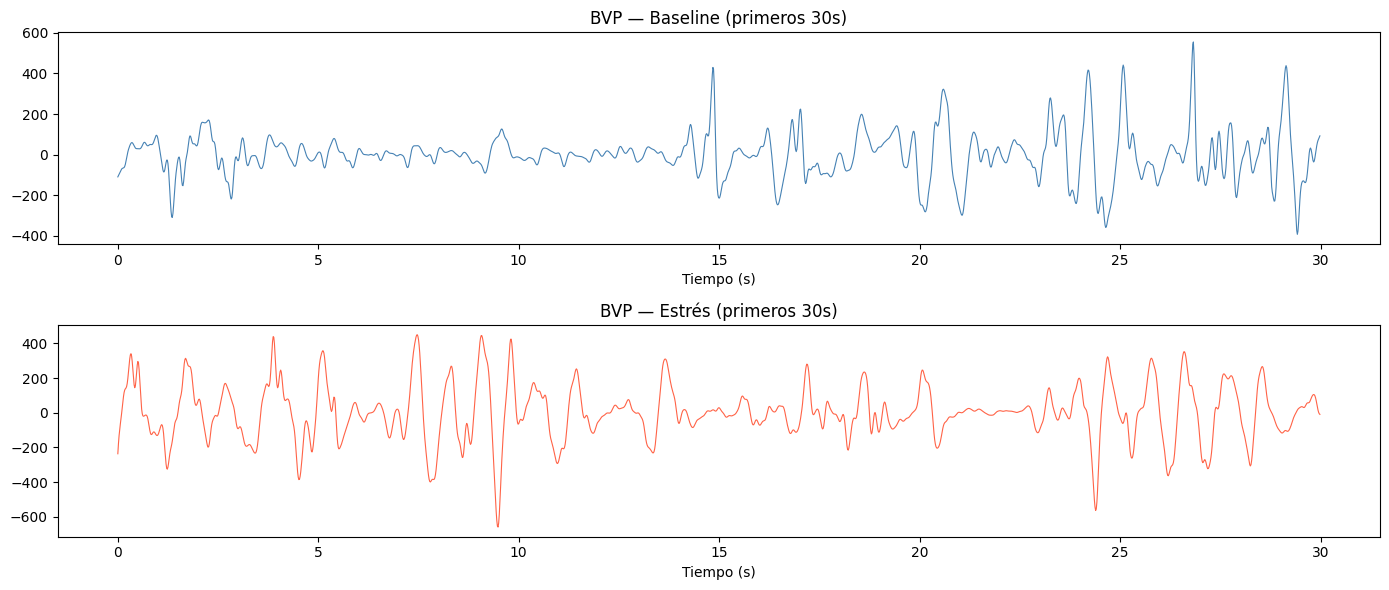

In [12]:
# Creamos una figura con 2 gráficos (subplots), uno arriba del otro
# figsize → tamaño de la figura (ancho, alto)
fig, axes = plt.subplots(2, 1, figsize=(14, 6))


# =======================
# 📉 BVP en BASELINE
# =======================

# Creamos un eje de tiempo en segundos
# len(baseline_bvp) → cantidad de muestras
# /64 → porque la señal está a 64 Hz (64 muestras = 1 segundo)
t_baseline = np.arange(len(baseline_bvp)) / 64

# Graficamos SOLO los primeros 30 segundos:
# 64 * 30 = 1920 muestras
axes[0].plot(
    t_baseline[:64*30], 
    baseline_bvp[:64*30], 
    color='steelblue', 
    lw=0.8
)

# Título y etiqueta del eje X
axes[0].set_title("BVP — Baseline (primeros 30s)")
axes[0].set_xlabel("Tiempo (s)")


# =======================
# 😰 BVP en ESTRÉS
# =======================

# Mismo proceso pero con la señal de estrés
t_stress = np.arange(len(stress_bvp)) / 64

axes[1].plot(
    t_stress[:64*30], 
    stress_bvp[:64*30], 
    color='tomato', 
    lw=0.8
)

axes[1].set_title("BVP — Estrés (primeros 30s)")
axes[1].set_xlabel("Tiempo (s)")


# Ajusta automáticamente los espacios entre gráficos
plt.tight_layout()

# Muestra la figura final
plt.show()

In [ ]:
"** Extraer HR y HRV por ventanas**"

In [13]:
# Función para extraer features fisiológicas desde un segmento de BVP
def extraer_features(bvp_segment, fs=64):
    try:
        # Procesa la señal PPG (fotopletismografía)
        # Detecta picos, limpia ruido, etc.
        signals, info = nk.ppg_process(bvp_segment, sampling_rate=fs)

        # 💓 Frecuencia cardíaca promedio (Heart Rate)
        # PPG_Rate ya viene en BPM (latidos por minuto)
        hr_mean = signals['PPG_Rate'].mean()

        # ❤️ Variabilidad cardíaca (HRV)
        # RMSSD = métrica clave de variabilidad entre latidos
        # Muy usada para detectar estrés
        rmssd = nk.hrv_time(info, sampling_rate=fs)['HRV_RMSSD'].values[0]

        return hr_mean, rmssd

    except:
        # Si falla (ruido, mala señal, etc.), devolvemos NaN
        return np.nan, np.nan

# Definimos cómo vamos a dividir la señal

VENTANA_SEG = 60   # tamaño de cada ventana → 60 segundos
PASO_SEG = 30      # cuánto avanzamos → 30 segundos (overlap del 50%)
fs = 64            # frecuencia de muestreo

resultados = []

# Recorremos cada clase con su señal correspondiente
for clase, bvp_seg in [(1, baseline_bvp), (2, stress_bvp)]:
    ventana = VENTANA_SEG * fs   # cantidad de muestras en 60s
    paso = PASO_SEG * fs         # cantidad de muestras en 30s
    for inicio in range(0, len(bvp_seg) - ventana, paso):
        segmento = bvp_seg[inicio:inicio + ventana]
        hr, rmssd = extraer_features(segmento)
        resultados.append({'clase': clase, 'hr_mean': hr, 'rmssd': rmssd})

df = pd.DataFrame(resultados)
# Agrupamos por clase y vemos estadísticas
print(df.groupby('clase')[['hr_mean', 'rmssd']].describe().round(2))

      hr_mean                                                 rmssd          \
        count   mean   std    min    25%    50%    75%    max count    mean   
clase                                                                         
1        37.0  73.92  3.04  68.42  71.52  74.14  76.08  82.59  37.0  245.48   
2        19.0  71.59  4.28  63.69  69.53  71.26  73.28  80.56  19.0  497.67   

                                                       
          std     min     25%     50%     75%     max  
clase                                                  
1       86.07   84.63  195.33  241.94  285.14  515.97  
2      108.97  356.65  428.22  475.76  537.27  816.13  


In [ ]:
"HR (frecuencia cardíaca): va en la dirección correcta — baseline 73.9 BPM vs estrés 71.6 BPM. Pero la diferencia es muy pequeña y está "
"invertida respecto a lo esperado (estrés debería tener HR más alta). Esto es normal en WESAD con el S2, no todos los sujetos muestran "
"taquicardia clara."
"RMSSD (HRV): acá está el problema — estrés tiene RMSSD más alto (497 vs 245), que es lo opuesto a la literatura. En estrés agudo el RMSSD "
"debería bajar. Esto casi seguro es un problema de cómo neurokit2 está detectando los picos en el BVP crudo del E4, que tiene bastante ruido."

In [ ]:
"**Verificar detección de picos**"

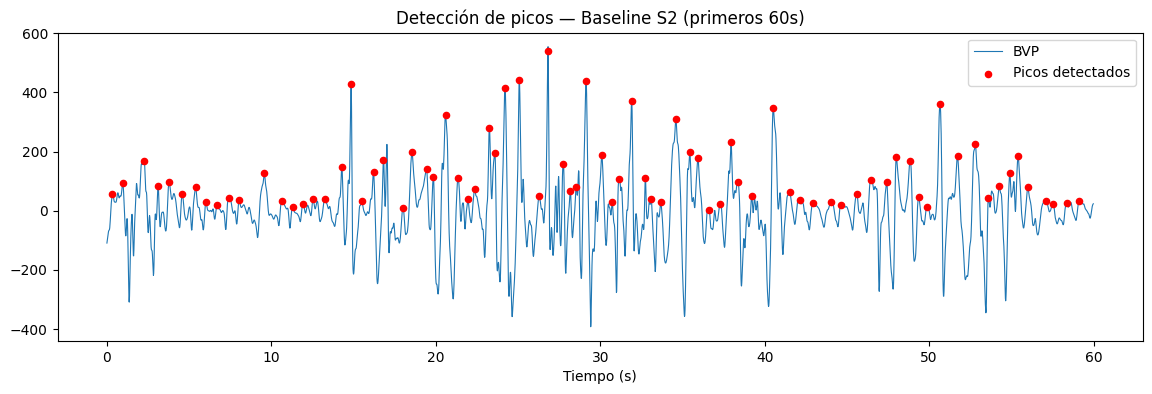

Picos detectados: 80
HR estimada: 80 picos en 60s → 80 BPM aprox


In [14]:
# Tomamos un segmento de prueba de 60 segundos del baseline
# 64 * 60 → 60 segundos a 64 Hz
segmento_test = baseline_bvp[:64*60]

# Procesamos la señal PPG
# Esto limpia la señal y detecta eventos importantes (como picos = latidos)
signals, info = nk.ppg_process(segmento_test, sampling_rate=64)

# Creamos la figura
plt.figure(figsize=(14, 4))
plt.plot(np.arange(len(segmento_test))/64, segmento_test, lw=0.8, label='BVP')
# Extraemos los picos detectados (latidos)
picos = info['PPG_Peaks']
plt.scatter(picos/64, segmento_test[picos], color='red', s=20, zorder=5, label='Picos detectados')
plt.title("Detección de picos — Baseline S2 (primeros 60s)")
plt.xlabel("Tiempo (s)")
plt.legend()
plt.show()

# Cantidad total de picos detectados
print(f"Picos detectados: {len(picos)}")

# Estimación simple de frecuencia cardíaca:
# como el segmento dura 60s → cantidad de picos ≈ BPM
print(f"HR estimada: {len(picos):.0f} picos en 60s → {len(picos)} BPM aprox")

In [ ]:
"**Pipeline corregido con filtrado previo**"

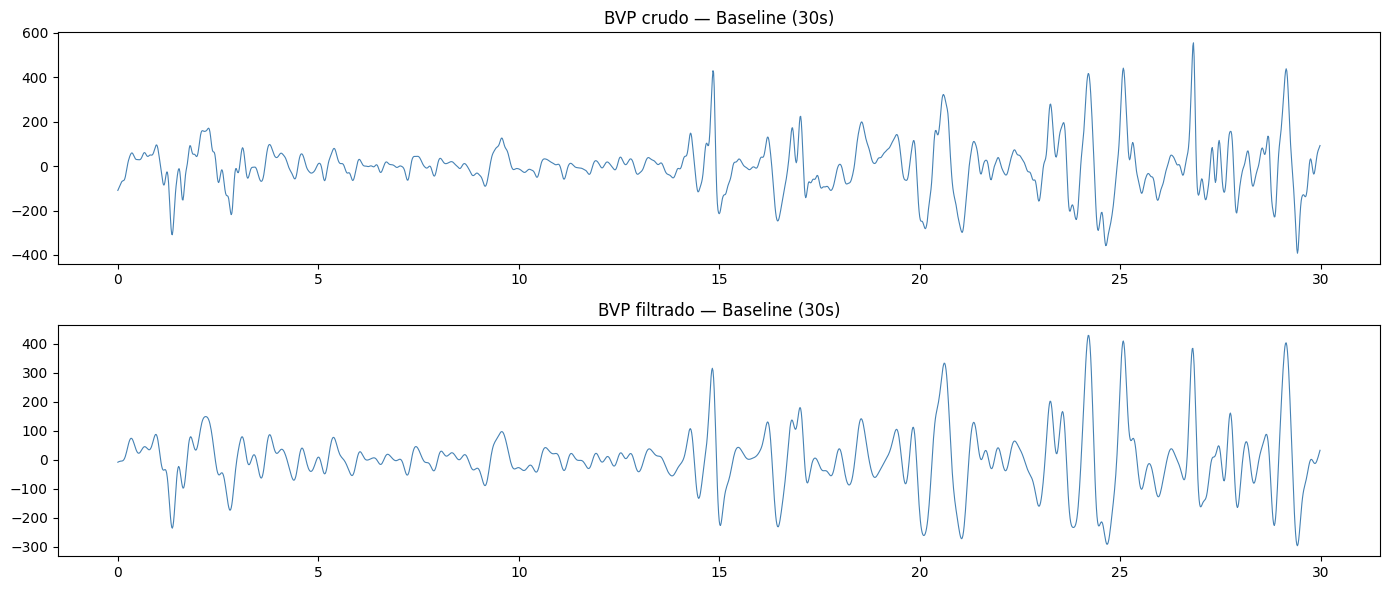

In [15]:
from scipy.signal import butter, filtfilt

# Definimos una función para filtrar la señal BVP
def filtrar_bvp(bvp, fs=64):

    # Creamos un filtro pasa banda:
    # - orden 3 → qué tan "fuerte" es el filtro
    # - [0.5, 4.0] Hz → rango de frecuencias que dejamos pasar
    #   (todo lo demás se elimina)
    # - fs=fs → frecuencia de muestreo (64 Hz)
    b, a = butter(3, [0.5, 4.0], btype='band', fs=fs)

    # Aplicamos el filtro a la señal
    # filtfilt lo hace hacia adelante y hacia atrás:
    # 👉 evita desfase (no corre la señal en el tiempo)
    return filtfilt(b, a, bvp)

# Tomamos un segmento de 30 segundos sin filtrar
segmento_raw = baseline_bvp[:64*30]

# Aplicamos el filtro
segmento_filtrado = filtrar_bvp(segmento_raw)

# Creamos dos gráficos (antes vs después)
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Eje de tiempo en segundos
t = np.arange(len(segmento_raw)) / 64

axes[0].plot(t, segmento_raw, lw=0.8, color='steelblue')
axes[0].set_title("BVP crudo — Baseline (30s)")

axes[1].plot(t, segmento_filtrado, lw=0.8, color='steelblue')
axes[1].set_title("BVP filtrado — Baseline (30s)")

plt.tight_layout()
plt.show()

In [ ]:
"**Verificar detección de picos sobre señal filtrada**"

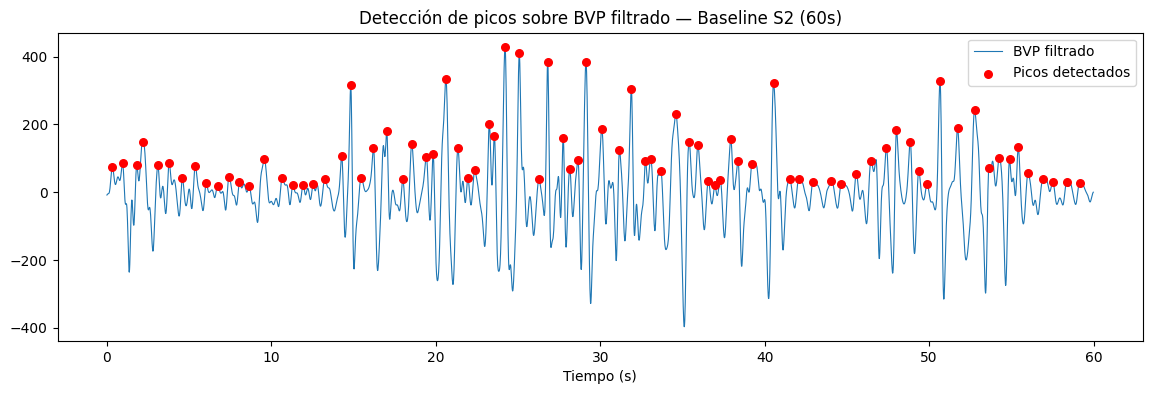

Picos detectados: 82
HR estimada: 82 BPM aprox


In [16]:
bvp_filtrado_test = filtrar_bvp(baseline_bvp[:64*60])
signals, info = nk.ppg_process(bvp_filtrado_test, sampling_rate=64)

plt.figure(figsize=(14, 4))
plt.plot(np.arange(len(bvp_filtrado_test))/64, bvp_filtrado_test, lw=0.8, label='BVP filtrado')
picos = info['PPG_Peaks']
plt.scatter(picos/64, bvp_filtrado_test[picos], color='red', s=30, zorder=5, label='Picos detectados')
plt.title("Detección de picos sobre BVP filtrado — Baseline S2 (60s)")
plt.xlabel("Tiempo (s)")
plt.legend()
plt.show()

print(f"Picos detectados: {len(picos)}")
print(f"HR estimada: {len(picos)} BPM aprox")

In [ ]:
"**Detección corregida**"

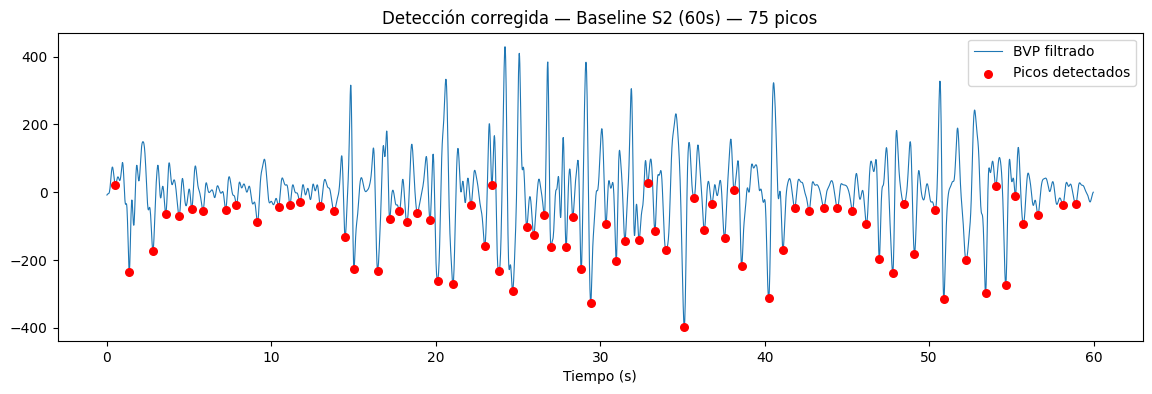

Picos detectados: 75
HR estimada: 75 BPM aprox
RR medio: 789 ms
RMSSD: 411.3 ms


In [17]:
from scipy.signal import find_peaks

# Función específica para detectar picos en señales del dispositivo E4
def detectar_picos_e4(bvp, fs=64):

    # 🔁 Invertimos la señal
    # En el E4, a veces los latidos aparecen como "valles" en vez de picos
    # Entonces los damos vuelta para poder usar find_peaks normalmente
    bvp_inv = -bvp
    picos, _ = find_peaks(bvp_inv, distance=int(fs * 0.4), prominence=50)
    return picos

# Tomamos 60 segundos y los filtramos (muy importante hacerlo antes)
segmento = filtrar_bvp(baseline_bvp[:64*60])

# Detectamos picos con nuestro método
picos = detectar_picos_e4(segmento)

plt.figure(figsize=(14, 4))
plt.plot(np.arange(len(segmento))/64, segmento, lw=0.8, label='BVP filtrado')
plt.scatter(picos/64, segmento[picos], color='red', s=30, zorder=5, label='Picos detectados')
plt.title(f"Detección corregida — Baseline S2 (60s) — {len(picos)} picos")
plt.xlabel("Tiempo (s)")
plt.legend()
plt.show()

print(f"Picos detectados: {len(picos)}")
print(f"HR estimada: {len(picos)} BPM aprox")

# Calcular intervalos RR
rr_intervals = np.diff(picos) / fs * 1000  # en milisegundos
# Promedio de intervalos RR
print(f"RR medio: {rr_intervals.mean():.0f} ms")
# RMSSD (variabilidad cardíaca)
print(f"RMSSD: {np.sqrt(np.mean(np.diff(rr_intervals)**2)):.1f} ms")

In [ ]:
"**Ajuste de prominence**"

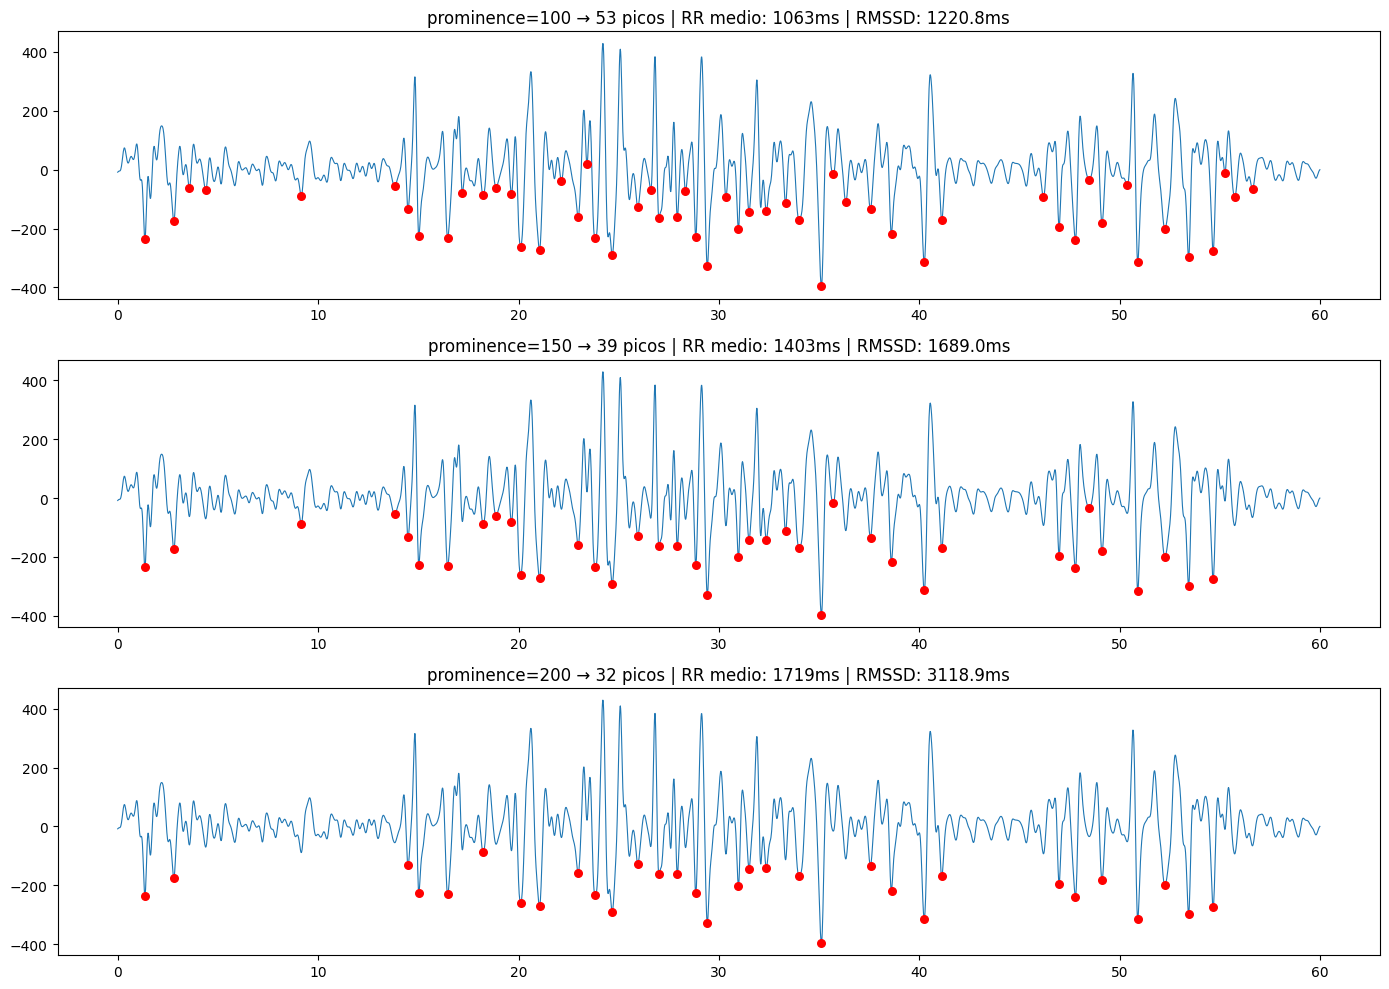

In [18]:
# Redefinimos la función agregando el parámetro "prominence"
def detectar_picos_e4(bvp, fs=64, prominence=100):

    # Invertimos la señal (latidos como valles → los volvemos picos)
    bvp_inv = -bvp

    # Detectamos picos con parámetros configurables
    picos, _ = find_peaks(
        bvp_inv,
        distance=int(fs * 0.4),  # mínimo 0.4s entre latidos (~150 BPM máx)
        prominence=prominence    # 👈 ahora lo vamos a ajustar
    )

    return picos

# Probar distintos valores de prominence
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Probamos distintos valores
for i, prom in enumerate([100, 150, 200]):
    # Tomamos 60s y filtramos
    segmento = filtrar_bvp(baseline_bvp[:64*60])
    # Detectamos picos con ese nivel de prominence
    picos = detectar_picos_e4(segmento, prominence=prom)
    rr = np.diff(picos) / 64 * 1000
    
        # Graficamos la señal
    axes[i].plot(np.arange(len(segmento))/64, segmento, lw=0.8)
    axes[i].scatter(picos/64, segmento[picos], color='red', s=30, zorder=5)
    axes[i].set_title(f"prominence={prom} → {len(picos)} picos | RR medio: {rr.mean():.0f}ms | RMSSD: {np.sqrt(np.mean(np.diff(rr)**2)):.1f}ms")

plt.tight_layout()
plt.show()

In [ ]:
"Ninguno de los tres está bien — los RR medios (1063ms, 1403ms, 1719ms) son todos demasiado altos, lo que significa que está perdiendo "
"latidos. Y los RMSSD son irrealmente altos porque los intervalos RR son inconsistentes."
"El problema de fondo es que este BVP tiene mucho ruido de movimiento y la morfología no es limpia. Cambiemos de estrategia completamente "
"— en lugar de buscar picos/valles manualmente, usemos el sensor de pecho del WESAD que tiene ECG limpio, y de ahí extraemos HR y HRV"
 "confiables para calibrar los umbrales."

In [ ]:
"**Usar ECG del pecho en lugar de BVP de muñeca**"

ECG: (4255300,) muestras → 101.3 minutos a 700 Hz
ECG baseline: 19.1 min
ECG estrés:   10.2 min


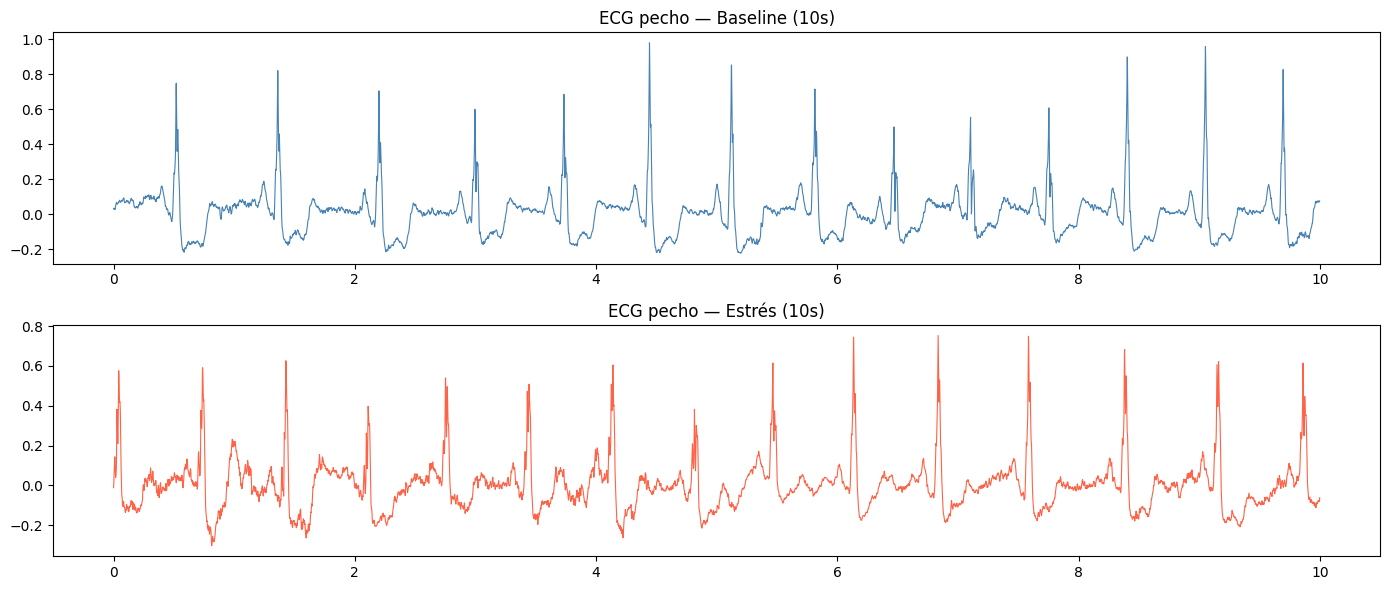

In [19]:
# Extraemos la señal ECG del pecho (chest)
# flatten() → la dejamos como vector 1D
# Frecuencia: 700 Hz → MUY alta resolución
ecg = data['signal']['chest']['ECG'].flatten()  # 700 Hz
labels_ecg = data['label'].flatten()            # ya está a 700 Hz, no necesita resampleo

print(f"ECG: {ecg.shape} muestras → {len(ecg)/700/60:.1f} minutos a 700 Hz")

# Separar por clase
baseline_ecg = ecg[labels_ecg == 1]
stress_ecg   = ecg[labels_ecg == 2]

print(f"ECG baseline: {len(baseline_ecg)/700/60:.1f} min")
print(f"ECG estrés:   {len(stress_ecg)/700/60:.1f} min")

# Creamos dos gráficos
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Eje de tiempo para 10 segundos
t = np.arange(700*10) / 700

axes[0].plot(t, baseline_ecg[:700*10], lw=0.8, color='steelblue')
axes[0].set_title("ECG pecho — Baseline (10s)")

axes[1].plot(t, stress_ecg[:700*10], lw=0.8, color='tomato')
axes[1].set_title("ECG pecho — Estrés (10s)")

plt.tight_layout()
plt.show()

In [ ]:
"**Extraer HR y HRV del ECG**"

In [21]:
# Función para extraer features desde ECG
def extraer_features_ecg(ecg_segment, fs=700):
    try:
        # Procesamiento completo de ECG:
        # - filtra
        # - detecta complejos QRS (latidos)
        # - calcula señales derivadas
        signals, info = nk.ecg_process(ecg_segment, sampling_rate=fs)

        # 💓 Frecuencia cardíaca promedio (BPM)
        hr_mean = signals['ECG_Rate'].mean()

        # ❤️ HRV (variabilidad cardíaca)
        rmssd = nk.hrv_time(info, sampling_rate=fs)['HRV_RMSSD'].values[0]

        return hr_mean, rmssd

    except:
        # Si algo falla (ruido, segmento malo, etc.)
        return np.nan, np.nan

# Configuración de ventanas (igual que antes)
VENTANA_SEG = 60   # 60 segundos
PASO_SEG = 30      # overlap del 50%
fs_ecg = 700       # frecuencia de ECG

resultados_ecg = []

for clase, ecg_seg in [(1, baseline_ecg), (2, stress_ecg)]:
        ventana = VENTANA_SEG * fs_ecg   # 60s → 42000 muestras 😵
    paso = PASO_SEG * fs_ecg         # 30s → 21000 muestras
    for inicio in range(0, len(ecg_seg) - ventana, paso):
        segmento = ecg_seg[inicio:inicio + ventana]
        hr, rmssd = extraer_features_ecg(segmento)
        resultados_ecg.append({'clase': clase, 'hr_mean': hr, 'rmssd': rmssd})

df_ecg = pd.DataFrame(resultados_ecg)
print(df_ecg.groupby('clase')[['hr_mean', 'rmssd']].describe().round(2))

      hr_mean                                                 rmssd         \
        count   mean   std    min    25%    50%    75%    max count   mean   
clase                                                                        
1        37.0  72.30  2.40  69.25  70.45  72.03  73.20  80.76  37.0  54.29   
2        19.0  76.87  3.22  73.43  73.99  75.99  79.55  83.00  19.0  39.65   

                                                
        std    min    25%    50%    75%    max  
clase                                           
1      6.88  43.19  49.73  52.39  59.36  71.76  
2      7.39  30.10  34.93  39.62  43.63  55.70  


In [ ]:
"**Visualización de distribuciones**"

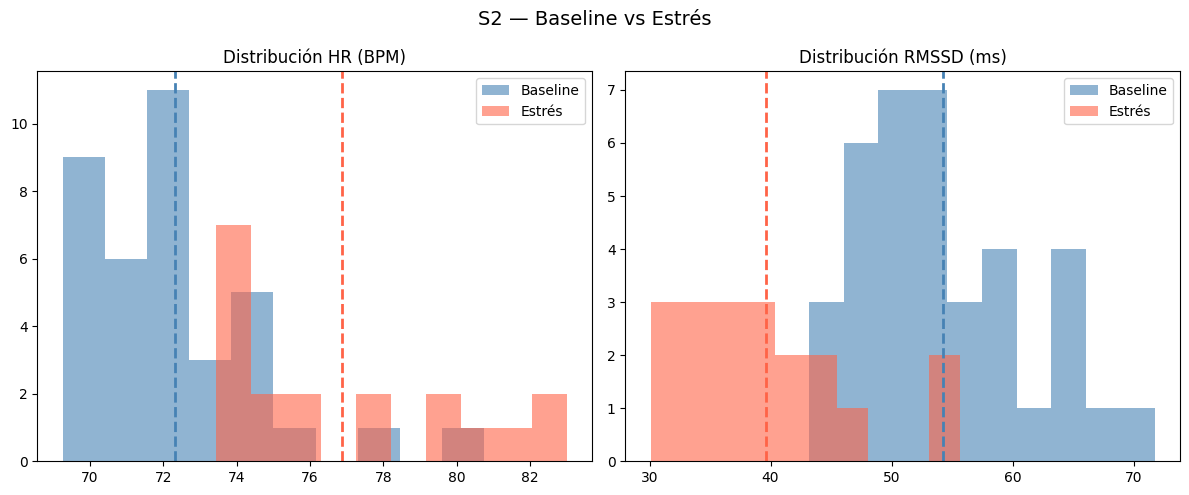

Umbral HR candidato:    > 74.6 BPM → posible estrés
Umbral RMSSD candidato: < 47.0 ms → posible estrés


In [22]:
# Creamos una figura con 2 gráficos (HR y RMSSD)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colores = {1: 'steelblue', 2: 'tomato'}
nombres = {1: 'Baseline', 2: 'Estrés'}

# Recorremos cada clase (baseline y estrés)
for clase in [1, 2]:

    # Filtramos el DataFrame solo para esa clase
    subset = df_ecg[df_ecg['clase'] == clase]
    # Histograma de HR (frecuencia cardíaca)
    axes[0].hist(subset['hr_mean'], alpha=0.6, bins=10,
                 color=colores[clase], label=nombres[clase])
    # Histograma de RMSSD (variabilidad)
    axes[1].hist(subset['rmssd'], alpha=0.6, bins=10,
                 color=colores[clase], label=nombres[clase])
# Promedios de HR
axes[0].axvline(df_ecg[df_ecg['clase']==1]['hr_mean'].mean(),
                color='steelblue', linestyle='--', lw=2)
axes[0].axvline(df_ecg[df_ecg['clase']==2]['hr_mean'].mean(),
                color='tomato', linestyle='--', lw=2)
axes[0].set_title("Distribución HR (BPM)")
axes[0].legend()

# Promedios de RMSSD
axes[1].axvline(df_ecg[df_ecg['clase']==1]['rmssd'].mean(),
                color='steelblue', linestyle='--', lw=2)
axes[1].axvline(df_ecg[df_ecg['clase']==2]['rmssd'].mean(),
                color='tomato', linestyle='--', lw=2)
axes[1].set_title("Distribución RMSSD (ms)")
axes[1].legend()

plt.suptitle("S2 — Baseline vs Estrés", fontsize=14)
plt.tight_layout()
plt.show()

# Umbrales candidatos
hr_umbral = (df_ecg[df_ecg['clase']==1]['hr_mean'].mean() +
             df_ecg[df_ecg['clase']==2]['hr_mean'].mean()) / 2
rmssd_umbral = (df_ecg[df_ecg['clase']==1]['rmssd'].mean() +
                df_ecg[df_ecg['clase']==2]['rmssd'].mean()) / 2

print(f"Umbral HR candidato:    > {hr_umbral:.1f} BPM → posible estrés")
print(f"Umbral RMSSD candidato: < {rmssd_umbral:.1f} ms → posible estrés")

In [ ]:
"Lo que muestra el gráfico:"
"En HR las distribuciones se solapan bastante pero el estrés está claramente desplazado a la derecha. En RMSSD la separación es más clara —"
"baseline concentrado en 50-65ms, estrés concentrado en 30-45ms."
"Los umbrales candidatos para S2:"

"HR > 74,6 BPM → señal de posible estrés"
"RMSSD < 47,0 ms → señal de posible estrés"

"Esto es solo un sujeto. Antes de usar estos números en KAIROS necesitás repetir el análisis para los 15 sujetos y promediar."

In [ ]:
"**Procesar todos los sujetos**"

In [24]:
import os

# Lista de sujetos del dataset WESAD
# S2 a S17, excluyendo S12 (datos incompletos)
SUJETOS = [f"S{i}" for i in range(2, 18) if i != 12]
resultados_todos = []

for sujeto in SUJETOS:
    pkl_path = f"{WESAD_PATH}/{sujeto}/{sujeto}.pkl"
    if not os.path.exists(pkl_path):
        print(f"{sujeto}: archivo no encontrado, saltando")
        continue
    
    print(f"Procesando {sujeto}...", end=' ')
    
    with open(pkl_path, 'rb') as f:
        d = pickle.load(f, encoding='latin1')
    
       # Extraemos ECG y labels
    ecg_s = d['signal']['chest']['ECG'].flatten()
    labels_s = d['label'].flatten()
    
    # Separar por clase
    baseline_s = ecg_s[labels_s == 1]
    stress_s   = ecg_s[labels_s == 2]
    
    fs_ecg = 700
    ventana = 60 * fs_ecg
    paso = 30 * fs_ecg
    
        # Recorremos baseline y estrés
    for clase, seg in [(1, baseline_s), (2, stress_s)]:
        for inicio in range(0, len(seg) - ventana, paso):
            # Extraer features del segmento
            hr, rmssd = extraer_features_ecg(seg[inicio:inicio+ventana])
            resultados_todos.append({
                'sujeto': sujeto,
                'clase': clase,
                'hr_mean': hr,
                'rmssd': rmssd
            })
    
    print("✓")

df_todos = pd.DataFrame(resultados_todos)
print("\n--- RESUMEN GLOBAL ---")
print(df_todos.groupby('clase')[['hr_mean', 'rmssd']].mean().round(2))

Procesando S2... 

/tmp/ipykernel_10406/364812778.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(f, encoding='latin1')


✓
Procesando S3... 

/tmp/ipykernel_10406/364812778.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(f, encoding='latin1')


✓
Procesando S4... 

...

✓
Procesando S16... 

/tmp/ipykernel_10406/364812778.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(f, encoding='latin1')


✓
Procesando S17... 

/tmp/ipykernel_10406/364812778.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(f, encoding='latin1')


✓

--- RESUMEN GLOBAL ---
       hr_mean  rmssd
clase                
1        72.44  51.04
2        97.94  35.75


In [ ]:
"Excelentes resultados. Estos son los números globales sobre los 15 sujetos:"
"HR:"

"Baseline: 72,4 BPM"
"Estrés: 97,9 BPM"
"Diferencia de +25,5 BPM — mucho más pronunciada que en S2 solo ✓"

"RMSSD:"

"Baseline: 51,0 ms"
"Estrés: 35,7 ms"
"Diferencia de -15,3 ms ✓"

In [ ]:
"** Umbrales finales**"

In [25]:
# Promedios globales de HR por clase
hr_base  = df_todos[df_todos['clase']==1]['hr_mean'].mean()
hr_stress = df_todos[df_todos['clase']==2]['hr_mean'].mean()
# Promedios globales de RMSSD
rmssd_base  = df_todos[df_todos['clase']==1]['rmssd'].mean()
rmssd_stress = df_todos[df_todos['clase']==2]['rmssd'].mean()

# Umbrales globales (punto medio entre clases)
hr_umbral_global    = (hr_base + hr_stress) / 2
rmssd_umbral_global = (rmssd_base + rmssd_stress) / 2

print("=== UMBRALES KAIROS (base WESAD, 15 sujetos) ===")
print(f"HR umbral:    > {hr_umbral_global:.1f} BPM → activar pre-alerta")
print(f"RMSSD umbral: < {rmssd_umbral_global:.1f} ms → activar pre-alerta")
print()
print("=== CONDICIÓN DE DETECCIÓN ===")
print(f"Crisis probable si: HR > {hr_umbral_global:.1f} BPM  AND  RMSSD < {rmssd_umbral_global:.1f} ms")

# Guardar
import json
umbrales = {
    "hr_umbral_bpm": round(hr_umbral_global, 1),
    "rmssd_umbral_ms": round(rmssd_umbral_global, 1),
    "hr_baseline_mean": round(hr_base, 1),
    "hr_stress_mean": round(hr_stress, 1),
    "rmssd_baseline_mean": round(rmssd_base, 1),
    "rmssd_stress_mean": round(rmssd_stress, 1),
    "dataset": "WESAD",
    "n_sujetos": 15,
    "ventana_seg": 60
}

with open("umbrales_kairos.json", "w") as f:
    json.dump(umbrales, f, indent=2)

print("\nGuardado en umbrales_kairos.json ✓")

=== UMBRALES KAIROS (base WESAD, 15 sujetos) ===
HR umbral:    > 85.2 BPM → activar pre-alerta
RMSSD umbral: < 43.4 ms → activar pre-alerta

=== CONDICIÓN DE DETECCIÓN ===
Crisis probable si: HR > 85.2 BPM  AND  RMSSD < 43.4 ms

Guardado en umbrales_kairos.json ✓


In [ ]:
"**Análisis del acelerómetro**"

Magnitud ACC baseline — media: 63.377, std: 3.386
Magnitud ACC estrés   — media: 62.937, std: 2.737


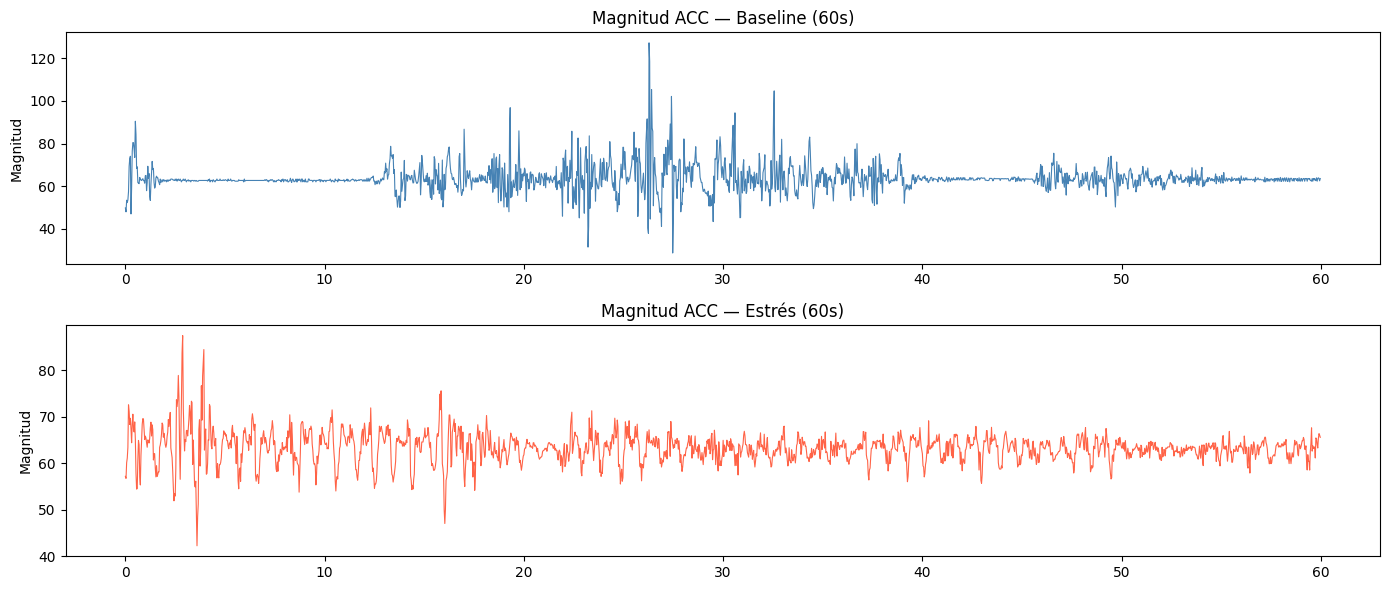

In [27]:
# ACC de muñeca a 32 Hz
acc = data['signal']['wrist']['ACC']  # shape (N, 3)

# Sincronizar labels a 32 Hz
indices_acc = np.linspace(0, len(labels)-1, len(acc))
labels_32hz = np.interp(indices_acc, np.arange(len(labels)), labels)
labels_32hz = np.round(labels_32hz).astype(int)

# Separar por clase
baseline_acc = acc[labels_32hz == 1]
stress_acc   = acc[labels_32hz == 2]

# Magnitud del vector (los 3 ejes combinados)
def magnitud(acc_segment):
    return np.sqrt(acc_segment[:,0]**2 + acc_segment[:,1]**2 + acc_segment[:,2]**2)

mag_baseline = magnitud(baseline_acc)
mag_stress   = magnitud(stress_acc)

print(f"Magnitud ACC baseline — media: {mag_baseline.mean():.3f}, std: {mag_baseline.std():.3f}")
print(f"Magnitud ACC estrés   — media: {mag_stress.mean():.3f}, std: {mag_stress.std():.3f}")

# Visualizar
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
t_b = np.arange(len(mag_baseline)) / 32
t_s = np.arange(len(mag_stress)) / 32

axes[0].plot(t_b[:32*60], mag_baseline[:32*60], lw=0.8, color='steelblue')
axes[0].set_title("Magnitud ACC — Baseline (60s)")
axes[0].set_ylabel("Magnitud")

axes[1].plot(t_s[:32*60], mag_stress[:32*60], lw=0.8, color='tomato')
axes[1].set_title("Magnitud ACC — Estrés (60s)")
axes[1].set_ylabel("Magnitud")
    
plt.tight_layout()
plt.show()

In [ ]:
"Los números:"

"Baseline: 63,4 de magnitud media"
"Estrés: 62,9 de magnitud media"

"Son prácticamente iguales — diferencia de solo 0,4. Eso es muy bueno para KAIROS porque significa que durante el estrés del TSST el "
"sujeto no estaba moviéndose más que en baseline. Los dos estaban sentados quietos."